In [1]:
# comparing BIGFAM vs. other methods

In [5]:
import pandas as pd
import numpy as np
import os

# FRreg

In [27]:
# GS, UKB 둘 다 구해져있음

In [55]:
df_frreg = pd.DataFrame(
    columns=["cohort", "pheno", 
             "FRreg_1", "FRreg_2", "FRreg_3", "FRreg_123",
             "se_FRreg_1", "se_FRreg_2", "se_FRreg_3", "se_FRreg_123"]
)

In [56]:
def meta_Vg(df_frreg):
    """compute Vg from FR-reg in D=1,2,3 using IVW"""
    means = np.array(2**df_frreg["DOR"] * df_frreg["slope"])
    ses = np.array(2**df_frreg["DOR"] * df_frreg["se"])
    
    meta_se = np.sqrt(1 / np.sum((1 / ses)**2))
    meta_mean = np.sum(means / ses**2) * meta_se**2
    return meta_mean, meta_se

In [57]:
for cohort in ["GS", "UKB"]:
    path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{cohort}/frreg/DOR"
    fns = os.listdir(path)
    
    for fn in fns:
        if fn == "tmp":
            continue
        tmp = pd.read_csv(f"{path}/{fn}", sep='\t')
        pheno = fn.split(".")[0]
        Vgs = {}
        
        for d in [1, 2, 3]:
            slp = tmp.loc[tmp["DOR"] == d, "slope"].values[0]
            se = tmp.loc[tmp["DOR"] == d, "se"].values[0]
            Vg = 2**d * slp
            se_Vg = 2**d * se
            method = f"FRreg_{d}"
            Vgs[method] = Vg
            Vgs[f"se_{method}"] = se_Vg
            
        meta_mean, meta_se = meta_Vg(tmp)
        Vgs["FRreg_123"] = meta_mean
        Vgs["se_FRreg_123"] = meta_se
        
        df_tmp = pd.DataFrame(Vgs, index=[0])
        df_tmp["cohort"] = cohort
        df_tmp["pheno"] = pheno
        
        df_frreg = pd.concat([df_frreg, df_tmp])

In [58]:
df_frreg

,cohort,pheno,FRreg_1,FRreg_2,FRreg_3,FRreg_123,se_FRreg_1,se_FRreg_2,se_FRreg_3,se_FRreg_123
0,GS,FEV,0.523129,0.566397,0.723985,0.528326,0.011763,0.038137,0.131100,0.011199
0,GS,FVC,0.562541,0.573840,1.198203,0.568155,0.011735,0.038090,0.130762,0.011174
0,GS,FEF,0.352627,0.367701,0.530728,0.355314,0.012160,0.038613,0.133355,0.011555
0,GS,Potassium,0.291505,0.274878,0.182287,0.288993,0.010537,0.032314,0.108262,0.009975
0,GS,ratio,0.233915,0.244657,0.607616,0.237781,0.011659,0.036996,0.125676,0.011077
...,...,...,...,...,...,...,...,...,...,...
0,UKB,Mean_platelet__thrombocyte__volume,0.659084,0.659470,0.655242,0.658810,0.005882,0.020883,0.019476,0.005437
0,UKB,Hand_grip_strength__left_,0.331997,0.362049,0.399455,0.339782,0.005984,0.020601,0.019021,0.005501
0,UKB,Testosterone,0.193514,0.141807,0.190563,0.189477,0.006977,0.023660,0.021999,0.006403
0,UKB,Apolipoprotein_B,0.355996,0.291702,0.356417,0.351467,0.006257,0.021599,0.019955,0.005754


In [59]:
df_frreg["lower_FRreg_123"] = df_frreg["FRreg_123"] - 1.96 * df_frreg["se_FRreg_123"]

df_frreg["upper_FRreg_123"] = df_frreg["FRreg_123"] + 1.96 * df_frreg["se_FRreg_123"]

In [60]:
(df_frreg[["cohort", "pheno", "FRreg_123", "lower_FRreg_123", "upper_FRreg_123"]]
 .rename(columns={
     "FRreg_123": "Traditional",
     "lower_FRreg_123": "lower_Traditional",
     "upper_FRreg_123": "upper_Traditional",
     })
 .to_csv(
     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/frreg.tsv",
     sep='\t',
     index=False
     )
 )

# RDR

In [34]:
# phenotype + GRM matrix (relatives)
# UKB : `/data/jerrylee/data/UKB/grm_rel`에 GRM 존재
# GS : `/data/jerrylee/data/GS/GRM`에 GRM. 이거 DOR 별로 나눠서 데이터 불리기

In [64]:
df_rdr = pd.DataFrame(
    columns=["cohort", "pheno", 
             "RDR_PO", "RDR_GP",
             "se_RDR_PO", "se_RDR_GP"]
)

In [65]:
def get_unique_ids(df):
    return list(set(df["volid"]) | set(df["relid"]))

## RDR. UKB

In [66]:
df_pair = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/relative_information/relatives.formatted.info",
    sep='\t'
)
len(df_pair[df_pair["rcode"] == "PC"])

4741

In [155]:
pheno_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/phenotype"
pheno_fns = os.listdir(pheno_path)
for pheno_fn in pheno_fns:
    pheno = pheno_fn.split(".")[0]
    df_pheno = pd.read_csv(f"{pheno_path}/{pheno_fn}", sep='\t')
    
    for rcode in ["PC"]:
        target_pairs = df_pair[df_pair["rcode"] == rcode]
        target_ids = get_unique_ids(target_pairs)
        
        tmp = df_pheno[df_pheno["eid"].isin(target_ids)][["eid", "eid", "pheno"]].copy()
        tmp.columns = ["FID", "IID", "trait"]
        
        # save phenotype 
        tmp_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/tmp/{pheno}.txt"
        tmp.to_csv(tmp_fn, sep='\t', index=False)
        
        # run RDR
        cmd = "python /data/jerrylee/pjt/BIGFAM.v.0.1/BIGFAM/RELT.py {grm_id} {grm_bin} {pheno_fn} {out_fn}".format(
            grm_id = "/data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.id",
            grm_bin = "/data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.bin",
            pheno_fn = tmp_fn,
            out_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/RDR/{pheno}.{rcode}"
        )
        os.system(cmd)
        
        # remove phenotype file
        cmd = f"rm {tmp_fn}"
        os.system(cmd)

IDs of 17057 individuals read for relatedness matrices

Non-missing phenotypes of 8308 individuals included
7364 individuals with both relatedness and trait information
Reading /data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.bin
Computing regression estimate
5.766145505426396e-09
0.0003719777388877882
v: 0.212
Phenotypic variance estimate: 1.154
Estimating heritability
7518 pairs with relatedness >0.05 excluded
Computing regression estimate
9.517099582947482e-08
0.001148691809162864
v_g: 0.068
Estimating standard error
v_g: 0.068 (0.065)
Estimating variance of phenotypic variance estimate
Estimating covariance between genetic variance and phenotypic variance estimate
v_g/v_y: 0.059 (0.0559)
IDs of 17057 individuals read for relatedness matrices

Non-missing phenotypes of 8291 individuals included
7348 individuals with both relatedness and trait information
Reading /data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.bin
Computing regression estimate
5.76603822111391e-09
0.000373544229414967

In [67]:
rdr_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/RDR"
fns = os.listdir(rdr_path)
ps = [fn.split(".")[0] for fn in fns]

for pheno in ps:
    Vg_PC, se_PC, Vg_GP, se_GP = None, None, None, None
    
    target_fns = [fn for fn in fns if fn.split(".")[0] == pheno]
    
    for fn in target_fns:
        rcode = fn.split(".")[1]
        tmp = pd.read_csv(f"{rdr_path}/{fn}", sep='\t')
        
        if rcode == "PC":
            Vg_PC = tmp.iloc[3, 1]
            se_PC = tmp.iloc[3, 2]
        elif rcode == "GP":
            Vg_GP = tmp.iloc[3, 1]
            se_GP = tmp.iloc[3, 2]
            
    df_rdr.loc[len(df_rdr)] = ["UKB", pheno, Vg_PC, Vg_GP, se_PC, se_GP]

In [68]:
df_rdr

,cohort,pheno,RDR_PO,RDR_GP,se_RDR_PO,se_RDR_GP
0,UKB,"Forced_vital_capacity__FVC_,_Best_measure",0.206911,None,0.082001,None
1,UKB,Urate,0.444042,None,0.069230,None
2,UKB,Body_mass_index__BMI_,0.282368,None,0.070216,None
3,UKB,HDL_cholesterol,0.280034,None,0.073742,None
4,UKB,Platelet_count,0.344838,None,0.071308,None
...,...,...,...,...,...,...
101,UKB,High_light_scatter_reticulocyte_count,0.160975,None,0.060974,None
102,UKB,Creatinine__enzymatic__in_urine,0.033083,None,0.053154,None
103,UKB,Forced_expiratory_volume_in_1-second__FEV1_,0.132437,None,0.064311,None
104,UKB,Apolipoprotein_A,0.232224,None,0.070523,None


## RDR. GS

In [69]:
df_pair = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/relative_information/relatives.formatted.info",
    sep='\t'
)

In [70]:
len(df_pair[df_pair["rcode"] == "PC"]), len(df_pair[df_pair["rcode"] == "GP"])

(9811, 1426)

In [9]:
pheno_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/phenotype"
pheno_fns = os.listdir(pheno_path)

for pheno_fn in pheno_fns:
    pheno = pheno_fn.split(".")[0]
    df_pheno = pd.read_csv(f"{pheno_path}/{pheno_fn}", sep='\t')
    
    for rcode in ["PC", "GP"]:
        target_pairs = df_pair[df_pair["rcode"] == rcode]
        target_ids = get_unique_ids(target_pairs)
        
        tmp = df_pheno[df_pheno["eid"].isin(target_ids)][["eid", "eid", "pheno"]].copy()
        tmp.columns = ["FID", "IID", "trait"]
        
        # save phenotype 
        tmp_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/tmp/{pheno}.txt"
        tmp.to_csv(tmp_fn, sep='\t', index=False)
        
        # run RDR
        cmd = "python /data/jerrylee/pjt/BIGFAM.v.0.1/BIGFAM/RELT.py {grm_id} {grm_bin} {pheno_fn} {out_fn}".format(
            grm_id = "/data/jerrylee/data/GS/GRM/GS_GWAS.grm.id",
            grm_bin = "/data/jerrylee/data/GS/GRM/GS_GWAS.grm.bin",
            pheno_fn = tmp_fn,
            out_fn = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/RDR/{pheno}.{rcode}"
        )
        os.system(cmd)
        
        # remove phenotype file
        cmd = f"rm {tmp_fn}"
        os.system(cmd)

IDs of 19982 individuals read for relatedness matrices

Non-missing phenotypes of 12597 individuals included
12597 individuals with both relatedness and trait information
Reading /data/jerrylee/data/GS/GRM/GS_GWAS.grm.bin
Computing regression estimate
3.4528061387437554e-09
9.785682373699704e-05
v: 0.003
Phenotypic variance estimate: 0.524
Estimating heritability
42370 pairs with relatedness >0.05 excluded
Computing regression estimate
4.698145666262497e-08
0.00034283156918325184
v_g: -0.0
Estimating standard error
v_g: -0.0 (0.014)
Estimating variance of phenotypic variance estimate
Estimating covariance between genetic variance and phenotypic variance estimate
v_g/v_y: -0.001 (0.0264)
IDs of 19982 individuals read for relatedness matrices

Non-missing phenotypes of 1121 individuals included
1121 individuals with both relatedness and trait information
Reading /data/jerrylee/data/GS/GRM/GS_GWAS.grm.bin
Computing regression estimate
-1.5260147110735216e-06
0.004193080612098222
v: 0.002


In [71]:
rdr_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/RDR"
fns = os.listdir(rdr_path)
ps = [fn.split(".")[0] for fn in fns]

for pheno in ps:
    Vg_PC, se_PC, Vg_GP, se_GP = None, None, None, None
    
    target_fns = [fn for fn in fns if fn.split(".")[0] == pheno]
    
    for fn in target_fns:
        rcode = fn.split(".")[1]
        tmp = pd.read_csv(f"{rdr_path}/{fn}", sep='\t')
        
        if rcode == "PC":
            Vg_PC = tmp.iloc[3, 1]
            se_PC = tmp.iloc[3, 2]
        elif rcode == "GP":
            Vg_GP = tmp.iloc[3, 1]
            se_GP = tmp.iloc[3, 2]
            
    df_rdr.loc[len(df_rdr)] = ["GS", pheno, Vg_PC, Vg_GP, se_PC, se_GP]

In [72]:
for coln in ["RDR_PO", "RDR_GP"]:
    df_rdr[f"lower_{coln}"] = df_rdr[coln] - 1.96 * df_rdr[f"se_{coln}"]
    df_rdr[f"upper_{coln}"] = df_rdr[coln] + 1.96 * df_rdr[f"se_{coln}"]

In [73]:
df_rdr

,cohort,pheno,RDR_PO,RDR_GP,se_RDR_PO,se_RDR_GP,lower_RDR_PO,upper_RDR_PO,lower_RDR_GP,upper_RDR_GP
0,UKB,"Forced_vital_capacity__FVC_,_Best_measure",0.206911,NaN,0.082001,NaN,0.046189,0.367633,NaN,NaN
1,UKB,Urate,0.444042,NaN,0.069230,NaN,0.308351,0.579732,NaN,NaN
2,UKB,Body_mass_index__BMI_,0.282368,NaN,0.070216,NaN,0.144744,0.419991,NaN,NaN
3,UKB,HDL_cholesterol,0.280034,NaN,0.073742,NaN,0.135499,0.424568,NaN,NaN
4,UKB,Platelet_count,0.344838,NaN,0.071308,NaN,0.205075,0.484602,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
181,GS,absi,-0.157286,1.463438,0.258854,2.953317,-0.664640,0.350069,-4.325064,7.251940
182,GS,FVC,0.478383,-0.112615,0.070218,0.424793,0.340755,0.616011,-0.945210,0.719979
183,GS,QRS_duration,-0.000423,0.470165,0.026178,0.320643,-0.051731,0.050885,-0.158296,1.098626
184,GS,ECG_Count,-0.003379,-0.050964,0.024119,0.263491,-0.050653,0.043895,-0.567406,0.465478


In [74]:
target_colns = [
    "cohort", "pheno", 
    "RDR_PO", "lower_RDR_PO", "upper_RDR_PO", 
    "RDR_GP", "lower_RDR_GP", "upper_RDR_GP", 
]
(df_rdr[target_colns]
 .to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/RDR.tsv",
    sep='\t',
    index=False
))

# Sibreg

In [172]:
# phenotype + GRM (relatives)
# UKB : grm 사용
# GS : 역시 grm 사용

In [48]:
def get_unique_ids(df):
    return list(set(df["volid"]) | set(df["relid"]))

In [49]:
df_sibreg = pd.DataFrame(
    columns=["cohort", "pheno", 
             "sibreg", "se_sibreg"],
)

In [ ]:

for cohort in ["GS", "UKB"]:
    # read relative pair information
    info_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{cohort}/relative_information/relatives.formatted.info"
    df_pair = pd.read_csv(info_path, sep='\t')
    
    target_pairs = df_pair[df_pair["rcode"] == "SB"]
    target_ids = get_unique_ids(target_pairs)
    
    # load GRM
    if cohort == "GS":
        grm_id_fn = "/data/jerrylee/data/GS/GRM/GS_GWAS.grm.id"
        grm_bin_fn = "/data/jerrylee/data/GS/GRM/GS_GWAS.grm.bin"
    elif cohort == "UKB":
        grm_id_fn = "/data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.id"
        grm_bin_fn = "/data/jerrylee/data/UKB/grm_rel/DOR1_chrALL.grm.bin"
    
    # read id in GRM
    ids = np.loadtxt(grm_id_fn, dtype='S10')
    if len(ids.shape) > 1:
        if cohort == "UKB":
            ids = ids[:, 0]
        elif cohort == "GS":
            ids = ids[:, 1] # GS    
        else:
            raise
    N = len(ids)
    id_dict = {}
    for i in range(0, N):
        ids_str = ids[i].decode("utf-8")
        id_dict[ids_str] = i
    
    # read GRM
    N = len(ids)
    R = np.zeros((N, N), dtype=np.float32)
    R[np.tril_indices(N)] = np.fromfile(grm_bin_fn, dtype=np.float32)
    R = R + R.T
    R[np.diag_indices(N)] = np.diag(R) / 2.0
    
    # read phenotype
    pheno_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{cohort}/phenotype"
    pheno_fns = os.listdir(pheno_path)
    
    for pheno_fn in tqdm(pheno_fns):
        pheno = pheno_fn.split(".")[0]
        df_tmp = pd.DataFrame(
            columns=["volid", "relid", "volpheno", "relpheno", "kinship"]
        )
        
        df_pheno = pd.read_csv(f"{pheno_path}/{pheno_fn}", sep='\t')
        tmp = df_pheno[df_pheno["eid"].isin(target_ids)].copy()
        tmp["pheno"] = (tmp["pheno"] - np.mean(tmp["pheno"])) / np.std(tmp["pheno"])
        tmp = tmp.astype({"eid": str, "pheno": float})
        id_in_phenos = tmp["eid"].unique()
        
        for _, row in target_pairs.iterrows():
            volid, relid = row[["volid", "relid"]]
            volid = str(volid)
            relid = str(relid)

            if not ((volid in id_in_phenos) & (relid in id_in_phenos)):
                continue
            
            volpheno = tmp.loc[tmp["eid"] == volid, "pheno"].values[0]
            relpheno = tmp.loc[tmp["eid"] == relid, "pheno"].values[0]
            
            try:
                ri = id_dict[str(volid)]
                ci = id_dict[str(relid)]
                kinship = R[ri, ci]
                
                df_tmp.loc[len(df_tmp)] = [volid, relid, volpheno, relpheno, kinship]
            except:
                continue
        
        # sibling regression
        df_tmp["cross_pheno"] = (df_tmp["volpheno"] - df_tmp["relpheno"])**2
        ll = smf.ols("cross_pheno ~ 1 + kinship", data=df_tmp).fit()
        vp = 0.5 * ll.params["Intercept"]
        se_vp = 0.5 * ll.bse["Intercept"]
        vg = -0.5 * ll.params["kinship"]
        se_vg = 0.5 * ll.bse["kinship"]
        
        hsq = vg / vp
        se_hsq = (vg / vp) * se_vg
        
        df_sibreg.loc[len(df_sibreg)] = [cohort, pheno, hsq, se_hsq]
        break

In [81]:
df_sibreg = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/sibreg.raw.tsv",
    sep='\t'
)

In [82]:
df_sibreg["lower_sibreg"] = df_sibreg["sibreg"] - 1.96 * df_sibreg["se_sibreg"]
df_sibreg["upper_sibreg"] = df_sibreg["sibreg"] + 1.96 * df_sibreg["se_sibreg"]

In [83]:
df_sibreg[(df_sibreg["sibreg"] > 0) & (df_sibreg["sibreg"] < 1)]

,cohort,pheno,sibreg,se_sibreg,lower_sibreg,upper_sibreg
1,GS,PR_interval,0.392006,1.225040,-2.009072,2.793084
2,GS,FVC,0.896587,0.236303,0.433433,1.359742
3,GS,HDL_cholesterol,0.434777,0.117452,0.204571,0.664984
4,GS,Creat_mgdl,0.975908,0.845323,-0.680926,2.632741
5,GS,max_arm,0.527822,0.180351,0.174335,0.881309
...,...,...,...,...,...,...
136,UKB,LDL_direct,0.062724,0.032046,-0.000087,0.125535
138,UKB,Impedance_of_whole_body,0.796056,0.390399,0.030873,1.561239
139,UKB,Forced_vital_capacity__FVC__Z-score,0.739559,0.474176,-0.189825,1.668943
141,UKB,Sitting_height,0.383940,0.203533,-0.014984,0.782864


In [84]:
target_colns = [
    "cohort", "pheno", 
    "sibreg", "lower_sibreg", "upper_sibreg", 
]
(df_sibreg[(df_sibreg["sibreg"] > 0) & (df_sibreg["sibreg"] < 1)][target_colns]
 .to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/sibreg.tsv",
    sep='\t',
    index=False
))

# LDSC

In [85]:
# using summary 
# UKB : summary 사용 (Neal's Lab에서 긁어옴)
# GS : X (relative라서 summary 만들어봣자 의미 없음)

In [86]:
df_raw = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/ldsc.raw.tsv",
    sep='\t'
)

In [87]:
df_raw.head()

,ID,pheno,description,h2_liability,h2_liability_se,h2_observed,h2_observed_se,h2_z,h2_p,h2_sig
0,30600_irnt,Albumin,Albumin (g/L),0.144611,0.009410,0.144611,0.009410,15.367925,1.343189e-53,z7
1,30610_irnt,Alkaline_phosphatase,Alkaline phosphatase (U/L),0.308597,0.066952,0.308597,0.066952,4.609224,2.020869e-06,NaN
2,30630_irnt,Apolipoprotein_A,Apoliprotein A (g/L),0.285172,0.062791,0.285172,0.062791,4.541622,2.791148e-06,NaN
3,30640_irnt,Apolipoprotein_B,Apoliprotein B (g/L),0.091511,0.021689,0.091511,0.021689,4.219324,1.225179e-05,z4
4,23125_irnt,Arm_fat-free_mass__left_,Arm fat-free mass (left),0.269922,0.010019,0.269922,0.010019,26.942153,3.524759e-160,z7


In [88]:
df_ldsc = pd.DataFrame(columns=["cohort", "pheno", "ldsc", "se_ldsc"])

for _, row in df_raw.iterrows():
    pheno, ldsc, se_ldsc = row[["pheno", "h2_liability", "h2_liability_se"]]
    
    df_ldsc.loc[len(df_ldsc)] = ["UKB", pheno, ldsc, se_ldsc]


In [89]:
df_ldsc["lower_ldsc"] = df_ldsc["ldsc"] - 1.96*df_ldsc["se_ldsc"] 
df_ldsc["upper_ldsc"] = df_ldsc["ldsc"] + 1.96*df_ldsc["se_ldsc"] 

In [90]:
df_ldsc

,cohort,pheno,ldsc,se_ldsc,lower_ldsc,upper_ldsc
0,UKB,Albumin,0.144611,0.009410,0.126167,0.163054
1,UKB,Alkaline_phosphatase,0.308597,0.066952,0.177371,0.439823
2,UKB,Apolipoprotein_A,0.285172,0.062791,0.162102,0.408242
3,UKB,Apolipoprotein_B,0.091511,0.021689,0.049002,0.134021
4,UKB,Arm_fat-free_mass__left_,0.269922,0.010019,0.250285,0.289558
...,...,...,...,...,...,...
88,UKB,Mean_sphered_cell_volume,0.200086,0.025019,0.151048,0.249124
89,UKB,Sitting_height,0.348691,0.016679,0.316000,0.381382
90,UKB,Standing_height,0.485223,0.021812,0.442472,0.527973
91,UKB,Trunk_fat-free_mass,0.298052,0.011476,0.275560,0.320545


In [91]:
target_colns = [
    "cohort", "pheno", 
    "ldsc", "lower_ldsc", "upper_ldsc", 
]

(df_ldsc[target_colns]
 .to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/ldsc.tsv",
    sep='\t',
    index=False
))

# LDpred2

In [ ]:
# using summary 
# UKB : summary 사용 (summary긁어와서 돌림)
# GS : X (relative라서 summary 만들어봣자 의미 없음)

In [ ]:
# https://privefl.github.io/bigsnpr/articles/LDpred2.html#which-set-of-variants-to-use

In [15]:
df_raw = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/LDpred2.raw.tsv",
    sep='\t',
)
df_raw.head()

,pheno,h2,lower,upper
0,Arm_fat-free_mass__left_,0.182970,0.179550,0.186558
1,Arm_fat-free_mass__right_,0.184147,0.180674,0.187685
2,Arm_fat_mass__left_,0.153206,0.149904,0.156531
3,Arm_fat_mass__right_,0.153098,0.149781,0.156381
4,Arm_fat_percentage__left_,0.147812,0.144527,0.151056


In [16]:
df_raw["cohort"] = "UKB"
df_raw = df_raw.rename(columns={"h2": "LDpred2", 
                                "lower": "lower_LDpred2",
                                "upper": "upper_LDpred2",})

In [19]:
(df_raw[["cohort", "pheno", "LDpred2", "lower_LDpred2", "upper_LDpred2"]]
 .to_csv(
     "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/LDpred2.tsv",
     sep='\t',
     index=False
 )
)

# BIGFAM

In [92]:
df_bigfam = pd.DataFrame(columns=["cohort", "pheno", "sig", "BIGFAM", "lower_BIGFAM", "upper_BIGFAM"])

for cohort in ["GS", "UKB"]:
    path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{cohort}/obj1"
    pheno_fns = os.listdir(path)
    phenos = list(set([p.split(".")[0] for p in pheno_fns]))
    
    for pheno in phenos:
        if pheno == "tmp":
            continue
        
        # prediction results
        fn = f"{path}/{pheno}.GSW"
        tmp = pd.read_csv(fn, sep='\t')
        Vg, lower, upper = tmp.loc[tmp["param"] == "V(g)", ["median", "lower(2.5%)", "upper(97.5%)"]].values[0]
        
        # significant results
        tmp_sig = pd.read_csv(
            f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{cohort}/FRLogreg/{pheno}.FRLOG",
            sep='\t'
        )
        slope_lower, slope_upper = tmp_sig.loc[tmp_sig["param"] == "slope", ["lower(2.5%)", "upper(97.5%)"]].values[0]
        
        sig = "None"
        if slope_lower > 1:
            sig = "High"
        elif slope_upper < 1:
            sig = "Low"
        
        df_bigfam.loc[len(df_bigfam)] = [cohort, pheno, sig, Vg, lower, upper]


In [93]:
df_bigfam

,cohort,pheno,sig,BIGFAM,lower_BIGFAM,upper_BIGFAM
0,GS,QRS_axis,None,0.000001,0.000001,0.000001
1,GS,QTC_interval,None,0.000001,0.000001,0.000001
2,GS,Creat_mgdl,Low,0.016493,0.000001,0.030981
3,GS,Creatinine,None,0.029398,0.000001,0.050112
4,GS,Heart_Rate,Low,0.197557,0.195314,0.199354
...,...,...,...,...,...,...
132,UKB,Eosinophill_percentage,None,0.002598,0.000001,0.007909
133,UKB,Monocyte_percentage,None,0.141565,0.000001,0.144673
134,UKB,Haematocrit_percentage,None,0.259896,0.223100,0.261650
135,UKB,Leg_fat_percentage__left_,Low,0.419052,0.418190,0.419761


In [94]:
df_bigfam.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods/bigfam.tsv",
    sep='\t',
    index=False
)

# Merge data

In [95]:
path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/methods"
methods = ["bigfam", "frreg", "RDR", "sibreg", "LDpred2", "ldsc"]

In [96]:
def left_nonzero(df, coln, condition="se"):
    if not (condition in ["se", "CI"]):
        raise
    
    is_01 = (df[f"{coln}"] < 1) & (df[f"{coln}"] > 0) 
    
    if condition == "se":
        is_nonzero = ((df[f"{coln}"] - 1.96 * df[f"se_{coln}"]) > 0)
        return df[is_nonzero & is_01].reset_index(drop=True)
    
    if condition == "CI":
        is_nonzero = (df[f"lower_{coln}"] > 1e-6)
        return df[is_nonzero & is_01].reset_index(drop=True)

In [97]:
tmp = pd.read_csv(
    f"{path}/bigfam.tsv",
    sep='\t'
)
df_bigfam = left_nonzero(tmp, "BIGFAM", condition="CI")

In [98]:
df_bigfam

,cohort,pheno,sig,BIGFAM,lower_BIGFAM,upper_BIGFAM
0,GS,Heart_Rate,Low,0.197557,0.195314,0.199354
1,GS,FVC,Low,0.295296,0.292953,0.298426
2,GS,max_arm,Low,0.137751,0.135022,0.140149
3,GS,HDL_cholesterol,Low,0.444004,0.440415,0.446869
4,GS,max_sys,Low,0.089542,0.088356,0.090780
...,...,...,...,...,...,...
97,UKB,Arm_predicted_mass__left_,Low,0.549630,0.548823,0.550545
98,UKB,Sodium_in_urine,Low,0.161834,0.160872,0.162837
99,UKB,Haematocrit_percentage,None,0.259896,0.223100,0.261650
100,UKB,Leg_fat_percentage__left_,Low,0.419052,0.418190,0.419761


In [100]:
tmp = pd.read_csv(
    f"{path}/frreg.tsv",
    sep='\t'
)

df_frreg = tmp
# df_frreg = (pd.merge(
#     tmp_1,
#     pd.merge(
#         tmp_2,
#         pd.merge(
#             tmp_3, 
#             tmp_123, 
#             on=["cohort", "pheno"], 
#             how="outer"
#             ),
#         on=["cohort", "pheno"], 
#             how="outer"
#         ),
#     on=["cohort", "pheno"], 
#             how="outer"
#     )
# )

In [120]:
tmp = pd.read_csv(
    f"{path}/RDR.tsv",
    sep='\t'
)
tmp_po = left_nonzero(
    tmp[["cohort", "pheno", "RDR_PO", "lower_RDR_PO", "upper_RDR_PO",]], 
    "RDR_PO", 
    condition="CI"
)
tmp_gp = left_nonzero(
    tmp[["cohort", "pheno", "RDR_GP", "lower_RDR_GP", "upper_RDR_GP",]], 
    "RDR_GP", 
    condition="CI"
)

In [121]:
tmp_po

,cohort,pheno,RDR_PO,lower_RDR_PO,upper_RDR_PO
0,UKB,"Forced_vital_capacity__FVC_,_Best_measure",0.206911,0.046189,0.367633
1,UKB,Urate,0.444042,0.308351,0.579732
2,UKB,Body_mass_index__BMI_,0.282368,0.144744,0.419991
3,UKB,HDL_cholesterol,0.280034,0.135499,0.424568
4,UKB,Platelet_count,0.344838,0.205075,0.484602
...,...,...,...,...,...
115,GS,height,0.644361,0.054220,1.234501
116,GS,FEV,0.342797,0.218135,0.467458
117,GS,expected,0.655578,0.477464,0.833692
118,GS,FVC,0.478383,0.340755,0.616011


In [122]:
tmp_gp

,cohort,pheno,RDR_GP,lower_RDR_GP,upper_RDR_GP
0,GS,avg_dia,0.586855,0.001468,1.172243
1,GS,avg_dia,0.586855,0.001468,1.172243


In [123]:
df_rdr = tmp_po.drop_duplicates(subset=["cohort", "pheno"])

In [124]:
df_rdr

,cohort,pheno,RDR_PO,lower_RDR_PO,upper_RDR_PO
0,UKB,"Forced_vital_capacity__FVC_,_Best_measure",0.206911,0.046189,0.367633
1,UKB,Urate,0.444042,0.308351,0.579732
2,UKB,Body_mass_index__BMI_,0.282368,0.144744,0.419991
3,UKB,HDL_cholesterol,0.280034,0.135499,0.424568
4,UKB,Platelet_count,0.344838,0.205075,0.484602
...,...,...,...,...,...
101,GS,max_leg,0.133180,0.041387,0.224972
104,GS,FEV,0.342797,0.218135,0.467458
106,GS,height,0.644361,0.054220,1.234501
108,GS,FVC,0.478383,0.340755,0.616011


In [104]:
tmp = pd.read_csv(
    f"{path}/sibreg.tsv",
    sep='\t'
)
df_sibreg = left_nonzero(tmp, "sibreg", condition="CI")
df_sibreg

,cohort,pheno,sibreg,lower_sibreg,upper_sibreg
0,GS,FVC,0.896587,0.433433,1.359742
1,GS,HDL_cholesterol,0.434777,0.204571,0.664984
2,GS,max_arm,0.527822,0.174335,0.881309
3,GS,avg_hr,0.563151,0.283080,0.843222
4,GS,FEF,0.515388,0.165725,0.865050
5,GS,avg_sys,0.217380,0.098536,0.336225
6,GS,max_leg,0.480317,0.192852,0.767782
7,GS,expected,0.951433,0.645146,1.257720
8,GS,Total_cholesterol,0.659592,0.323272,0.995912
9,GS,abpi,0.208613,0.060277,0.356950


In [105]:
tmp = pd.read_csv(
    f"{path}/LDpred2.tsv",
    sep='\t'
)
df_ldpred = left_nonzero(tmp, "LDpred2", condition="CI")

In [106]:
tmp = pd.read_csv(
    f"{path}/ldsc.tsv",
    sep='\t'
)
df_ldsc = left_nonzero(tmp, "ldsc", condition="CI")

In [125]:
df_mrg = pd.merge(
    df_ldsc,    
    pd.merge(
        df_ldpred,
        pd.merge(
            df_sibreg,
            pd.merge(
                df_rdr,
                pd.merge(
                    df_bigfam,
                    df_frreg,
                    on=["cohort", "pheno"],
                    how="outer"
                ),
                on=["cohort", "pheno"],
                how="outer"
            ),
            on=["cohort", "pheno"],
            how="outer"
        ),
        on=["cohort", "pheno"],
        how="outer"
    ),
    on=["cohort", "pheno"],
    how="outer"
)
df_mrg

,cohort,pheno,ldsc,lower_ldsc,upper_ldsc,LDpred2,lower_LDpred2,upper_LDpred2,sibreg,lower_sibreg,...,RDR_PO,lower_RDR_PO,upper_RDR_PO,sig,BIGFAM,lower_BIGFAM,upper_BIGFAM,Traditional,lower_Traditional,upper_Traditional
0,UKB,Albumin,0.144611,0.126167,0.163054,NaN,NaN,NaN,NaN,NaN,...,0.147819,0.022833,0.272805,None,0.296011,0.219414,0.312941,0.329298,0.317024,0.341573
1,UKB,Alkaline_phosphatase,0.308597,0.177371,0.439823,NaN,NaN,NaN,NaN,NaN,...,0.295251,0.158366,0.432136,None,0.124070,0.112879,0.333197,0.444976,0.433838,0.456114
2,UKB,Apolipoprotein_A,0.285172,0.162102,0.408242,NaN,NaN,NaN,0.136005,0.001611,...,0.232224,0.093999,0.370449,Low,0.448033,0.447102,0.448919,0.488691,0.476518,0.500863
3,UKB,Apolipoprotein_B,0.091511,0.049002,0.134021,NaN,NaN,NaN,0.564820,0.014519,...,0.197611,0.081339,0.313884,None,0.322178,0.225172,0.324078,0.351467,0.340189,0.362746
4,UKB,Arm_fat-free_mass__left_,0.269922,0.250285,0.289558,0.18297,0.17955,0.186558,0.849574,0.070036,...,0.227317,0.089032,0.365603,Low,0.554014,0.553294,0.554972,0.606697,0.596095,0.617299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,UKB,Interpolated_Age_of_participant_when_operation...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.092458,0.078731,0.106186
136,UKB,"Hair_colour__natural,_before_greying_",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.453052,0.442440,0.463664
137,UKB,Potassium_in_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129422,0.118241,0.140604
138,UKB,FEV1__FVC_ratio_Z-score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.388005,0.374755,0.401255


## Save Vg in each method

In [126]:
df_mrg.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.raw.tsv",
    sep='\t',
    index=False
)

In [127]:
df_mrg

,cohort,pheno,ldsc,lower_ldsc,upper_ldsc,LDpred2,lower_LDpred2,upper_LDpred2,sibreg,lower_sibreg,...,RDR_PO,lower_RDR_PO,upper_RDR_PO,sig,BIGFAM,lower_BIGFAM,upper_BIGFAM,Traditional,lower_Traditional,upper_Traditional
0,UKB,Albumin,0.144611,0.126167,0.163054,NaN,NaN,NaN,NaN,NaN,...,0.147819,0.022833,0.272805,None,0.296011,0.219414,0.312941,0.329298,0.317024,0.341573
1,UKB,Alkaline_phosphatase,0.308597,0.177371,0.439823,NaN,NaN,NaN,NaN,NaN,...,0.295251,0.158366,0.432136,None,0.124070,0.112879,0.333197,0.444976,0.433838,0.456114
2,UKB,Apolipoprotein_A,0.285172,0.162102,0.408242,NaN,NaN,NaN,0.136005,0.001611,...,0.232224,0.093999,0.370449,Low,0.448033,0.447102,0.448919,0.488691,0.476518,0.500863
3,UKB,Apolipoprotein_B,0.091511,0.049002,0.134021,NaN,NaN,NaN,0.564820,0.014519,...,0.197611,0.081339,0.313884,None,0.322178,0.225172,0.324078,0.351467,0.340189,0.362746
4,UKB,Arm_fat-free_mass__left_,0.269922,0.250285,0.289558,0.18297,0.17955,0.186558,0.849574,0.070036,...,0.227317,0.089032,0.365603,Low,0.554014,0.553294,0.554972,0.606697,0.596095,0.617299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,UKB,Interpolated_Age_of_participant_when_operation...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.092458,0.078731,0.106186
136,UKB,"Hair_colour__natural,_before_greying_",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.453052,0.442440,0.463664
137,UKB,Potassium_in_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129422,0.118241,0.140604
138,UKB,FEV1__FVC_ratio_Z-score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.388005,0.374755,0.401255


In [128]:
df_ukb = (df_mrg[df_mrg["cohort"] == "UKB"]
        #   .drop(columns=["RDR_GP", "lower_RDR_GP", "upper_RDR_GP"])
          .dropna())
df_gs = (df_mrg[df_mrg["cohort"] == "GS"]
          .drop(columns=["ldsc", "lower_ldsc", "upper_ldsc", "LDpred2", "lower_LDpred2", "upper_LDpred2"])
          .dropna())
df_filiterd = pd.concat([df_ukb, df_gs]).reset_index(drop=True)

In [141]:
df_filiterd.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.raw.tsv",
    sep='\t',
    index=False
)

In [130]:
df_filiterd.columns

Index(['cohort', 'pheno', 'ldsc', 'lower_ldsc', 'upper_ldsc', 'LDpred2',
       'lower_LDpred2', 'upper_LDpred2', 'sibreg', 'lower_sibreg',
       'upper_sibreg', 'RDR_PO', 'lower_RDR_PO', 'upper_RDR_PO', 'sig',
       'BIGFAM', 'lower_BIGFAM', 'upper_BIGFAM', 'Traditional',
       'lower_Traditional', 'upper_Traditional'],
      dtype='object')

In [132]:
df_to_save = (
    df_filiterd[
        ["cohort", "pheno", "sig", "BIGFAM", "Traditional", "RDR_PO", "sibreg", "LDpred2", "ldsc"]
    ]
    .rename(
        columns={
            "ldsc": "LDSC",
            "RDR_PO": "RDR",
            "sibreg": "SIBreg",
            "LDpred2": "LDpred"
            }
        )
)

df_to_save.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.filtered.tsv",
    sep='\t',
    index=False
)

In [137]:
df = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.filtered.tsv",
    sep='\t'
)

In [138]:
df.groupby("sig").size()

sig
High     1
Low     18
None     4
dtype: int64

In [139]:
df

,cohort,pheno,sig,BIGFAM,Traditional,RDR,SIBreg,LDpred,LDSC
0,UKB,Arm_fat-free_mass__left_,Low,0.554014,0.606697,0.227317,0.849574,0.182970,0.269922
1,UKB,Arm_fat-free_mass__right_,Low,0.525990,0.599312,0.239087,0.860901,0.184147,0.274690
2,UKB,Arm_predicted_mass__right_,Low,0.522262,0.597346,0.234957,0.905047,0.183720,0.274811
3,UKB,Body_mass_index__BMI_,Low,0.497295,0.580655,0.282368,0.330216,0.165579,0.248198
4,UKB,Impedance_of_whole_body,High,0.485292,0.553815,0.319217,0.796056,0.171956,0.268544
5,UKB,Trunk_fat_mass,None,0.458984,0.557317,0.151473,0.306025,0.157368,0.238672
6,UKB,Waist_circumference,None,0.393457,0.508702,0.129827,0.683447,0.131849,0.205681
7,UKB,Weight,None,0.521228,0.607882,0.191137,0.349812,0.178539,0.265415
8,UKB,Whole_body_fat-free_mass,Low,0.631006,0.680372,0.288323,0.884894,0.205505,0.302503
9,UKB,Whole_body_fat_mass,None,0.462424,0.564560,0.205743,0.171350,0.158204,0.239131


## Save ratio

In [133]:
colns = ["BIGFAM", "Traditional", "RDR", "SIBreg", "LDpred"]

for coln in colns:
    df_to_save[f"{coln}/LDSC"] = df_to_save[coln] / df_to_save["LDSC"]

In [134]:
df_ratio = df_to_save.drop(columns=colns + ["LDSC"]).dropna()

In [135]:
df_ratio_to_save = pd.DataFrame(
    columns=["pheno", "sig", "method", "ratio",]
)

for _, row in df_ratio.iterrows():
    pheno, sig = row[["pheno", "sig"]].values
    
    for method in colns:
        ratio = row[f"{method}/LDSC"]
    
        df_ratio_to_save.loc[len(df_ratio_to_save)]\
            = [pheno, "all", method, ratio]
            
        if sig != "None":
            df_ratio_to_save.loc[len(df_ratio_to_save)]\
            = [pheno, "sig", method, ratio]

In [136]:
df_ratio_to_save.to_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/figures/data/vs_snp.filtered.ratio.tsv",
    sep='\t',
    index=False
)

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt;

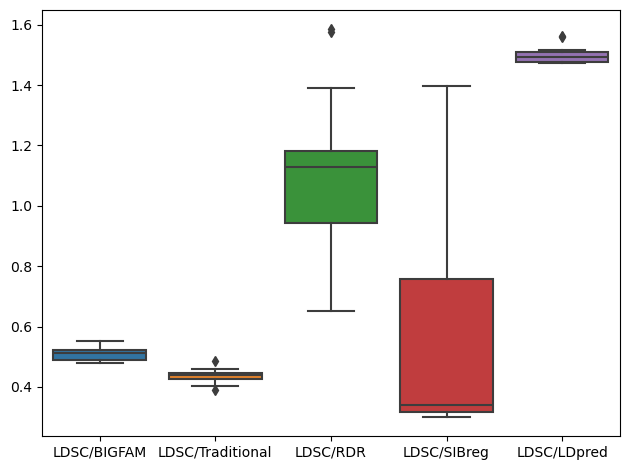

In [120]:
sns.boxplot(
    data=df_ratio
)
plt.tight_layout();